In [76]:
import torch

print(torch.backends.mps.is_available())

True


In [77]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

In [78]:
import pandas as pd
import re
import nltk
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import random

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

from nltk.corpus import stopwords, wordnet
from nltk import pos_tag
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import (Input, Embedding, Conv1D, GlobalMaxPooling1D,
                                     Dense, Dropout, Concatenate)
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/charlotecalosor/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/charlotecalosor/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/charlotecalosor/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/charlotecalosor/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

In [79]:
df = pd.read_csv('/Users/charlotecalosor/Downloads/CLEANED(with Rating)_dataset.csv')
df.head()

,Category,Rating,Label,Review
0,Home_and_Kitchen_5,5.0,CG,love this well made sturdy and very comfortab...
1,Home_and_Kitchen_5,5.0,CG,love it a great upgrade from the original ive...
2,Home_and_Kitchen_5,5.0,CG,this pillow saved my back i love the look and ...
3,Home_and_Kitchen_5,1.0,CG,missing information on how to use it but it is...
4,Home_and_Kitchen_5,5.0,CG,very nice set good quality we have had the set...


In [80]:
df.columns

Index(['Category', 'Rating', 'Label', 'Review'], dtype='object')

In [81]:
df

,Category,Rating,Label,Review
0,Home_and_Kitchen_5,5.0,CG,love this well made sturdy and very comfortab...
1,Home_and_Kitchen_5,5.0,CG,love it a great upgrade from the original ive...
2,Home_and_Kitchen_5,5.0,CG,this pillow saved my back i love the look and ...
3,Home_and_Kitchen_5,1.0,CG,missing information on how to use it but it is...
4,Home_and_Kitchen_5,5.0,CG,very nice set good quality we have had the set...
...,...,...,...,...
40406,Clothing_Shoes_and_Jewelry_5,4.0,OR,i had read some reviews saying that this bra r...
40407,Clothing_Shoes_and_Jewelry_5,5.0,CG,i wasnt sure exactly what it would be it is a ...
40408,Clothing_Shoes_and_Jewelry_5,2.0,OR,you can wear the hood by itself wear it with t...
40409,Clothing_Shoes_and_Jewelry_5,1.0,CG,i liked nothing about this dress the only reas...


In [82]:
le = LabelEncoder()
y = le.fit_transform(df['Label'])
print("Classes:", le.classes_)

Classes: ['CG' 'OR']


In [83]:
NUM_WORDS = 10000
MAX_LEN   = 100

tokenizer = Tokenizer(num_words=NUM_WORDS)
tokenizer.fit_on_texts(df['Review'])

X_text = tokenizer.texts_to_sequences(df['Review'])
X_text = pad_sequences(X_text, maxlen=MAX_LEN)
print("Text shape:", X_text.shape)


Text shape: (40411, 100)


In [84]:
scaler = MinMaxScaler()
X_rating = scaler.fit_transform(df[['Rating']])
print("Rating shape:", X_rating.shape)

Rating shape: (40411, 1)


In [85]:
X_text_temp, X_text_test, X_rating_temp, X_rating_test, y_temp, y_test = train_test_split(
    X_text, X_rating, y, test_size=0.10, random_state=42, stratify=y
)

X_text_train, X_text_val, X_rating_train, X_rating_val, y_train, y_val = train_test_split(
    X_text_temp, X_rating_temp, y_temp, test_size=0.111, random_state=42, stratify=y_temp
)

print(f"Train: {len(y_train)} | Val: {len(y_val)} | Test: {len(y_test)}")

Train: 32332 | Val: 4037 | Test: 4042


In [86]:
text_input = Input(shape=(MAX_LEN,), name='text_input')
x = Embedding(input_dim=NUM_WORDS + 1, output_dim=64)(text_input)
x = Conv1D(32, 5, activation='relu', kernel_regularizer=l2(0.01))(x)
x = GlobalMaxPooling1D()(x)
x = Dropout(0.6)(x)

# --- Rating branch ---
rating_input = Input(shape=(1,), name='rating_input')

# --- Combine both ---
combined = Concatenate()([x, rating_input])
combined = Dense(16, activation='relu', kernel_regularizer=l2(0.02))(combined)
combined = Dropout(0.6)(combined)
output = Dense(1, activation='sigmoid')(combined)

model = Model(inputs=[text_input, rating_input], outputs=output)

In [87]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)

model.compile(
    loss='binary_crossentropy',
    optimizer=optimizer,
    metrics=['accuracy']
)

In [88]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

history = model.fit(
    [X_text_train, X_rating_train],
    y_train,
    validation_data=([X_text_val, X_rating_val], y_val),
    epochs=20,
    batch_size=64,
    callbacks=[early_stop]
)


Epoch 1/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5452 - loss: 0.9480 - val_accuracy: 0.6693 - val_loss: 0.7247
Epoch 2/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6848 - loss: 0.6573 - val_accuracy: 0.8226 - val_loss: 0.5426
Epoch 3/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7949 - loss: 0.5484 - val_accuracy: 0.8643 - val_loss: 0.4546
Epoch 4/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8396 - loss: 0.4836 - val_accuracy: 0.8865 - val_loss: 0.4017
Epoch 5/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8615 - loss: 0.4418 - val_accuracy: 0.8979 - val_loss: 0.3708
Epoch 6/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8735 - loss: 0.4100 - val_accuracy: 0.9022 - val_loss: 0.3536
Epoch 7/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8872 - loss: 0.3850 - val_accuracy: 0.9009 - val_loss: 0.3400
Epoch 8/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8933 - loss: 0.3670 - val_accuracy: 0.

In [89]:
y_pred_prob = model.predict([X_text_test, X_rating_test])
y_pred = (y_pred_prob > 0.5).astype(int)

print(classification_report(y_test, y_pred, target_names=['CG', 'OR']))

127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 976us/step
              precision    recall  f1-score   support

          CG       0.92      0.89      0.91      2020
          OR       0.89      0.93      0.91      2022

    accuracy                           0.91      4042
   macro avg       0.91      0.91      0.91      4042
weighted avg       0.91      0.91      0.91      4042



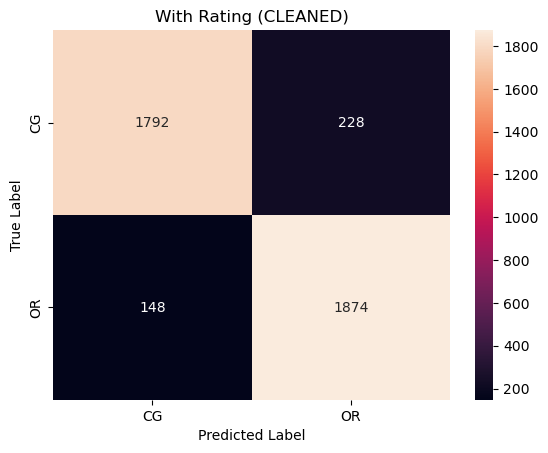

In [90]:
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['CG', 'OR'], yticklabels=['CG', 'OR'])
plt.title("With Rating (CLEANED)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

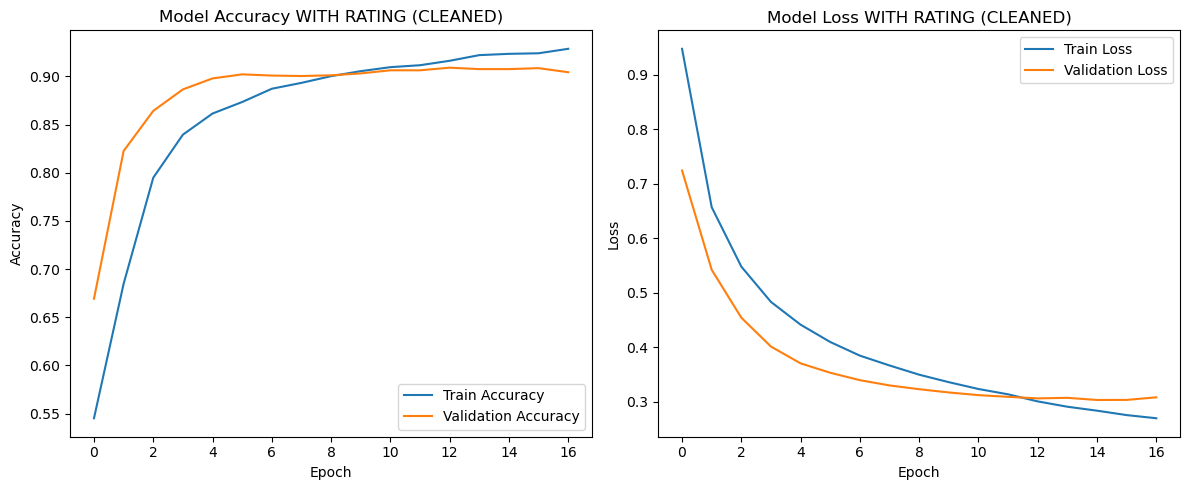

In [91]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy WITH RATING (CLEANED)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss WITH RATING (CLEANED)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
while True:
    new_text = input("\nEnter a review: ")
    
    if new_text.lower() == 'exit':
        print("Exiting prediction.")
        break

    new_seq = tokenizer.texts_to_sequences([new_text])
    new_padded = pad_sequences(new_seq, maxlen=MAX_LEN)
    default_rating = np.array([[0.5]])  # neutral, no scaler needed

    prediction = model.predict([new_padded, default_rating], verbose=0)

    if prediction[0][0] > 0.5:
        print(f"Prediction: OR (Original Review) — confidence: {prediction[0][0]:.2%}")
    else:
        print(f"Prediction: CG (Computer Generated) — confidence: {1 - prediction[0][0]:.2%}")


Enter a review:  The product is highly efficient and offers great value for the price. I am very satisfied with the overall quality and performance.


Prediction: OR (Original Review) — confidence: 97.70%



Enter a review:  This item arrived in excellent condition, the packaging was secure and the delivery was good.


Prediction: OR (Original Review) — confidence: 76.50%



Enter a review:  This device is easy to operate it meets the specifications in the product description.


Prediction: OR (Original Review) — confidence: 57.31%
